# Investor Risk Tolerance and Robo advisors

# 1. XÁC ĐỊNH BÀI TOÁN

Trong khuôn khổ học có giám sát cho bài toán hồi quy được sử dụng trong nghiên cứu tình huống này, biến dự đoán là mức độ chấp nhận rủi ro thực tế của một cá nhân, còn các biến dự báo là các thuộc tính về nhân khẩu học, tài chính và hành vi của cá nhân đó.

Mục tiêu của phần này là xây dựng một mô hình học máy để dự đoán mức độ chấp nhận rủi ro hoặc xu hướng né tránh rủi ro của nhà đầu tư, đồng thời ứng dụng mô hình này vào một bảng điều khiển robo-advisor.

# 2. DOWNLOAD PACKAGE VÀ DATASET

In [ ]:
import numpy as np
import pandas as pd
import pandas_datareader.data as web
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns
import copy
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.neural_network import MLPRegressor

from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD
from keras.layers import LSTM

import statsmodels.api as sm

from pickle import dump
from pickle import load

In [ ]:
dataset = pd.read_excel('SCFP2009panel.xlsx')

In [ ]:
type(dataset)

pandas.core.frame.DataFrame

In [ ]:
dataset.shape

(19285, 515)

# 3. TIỀN XỬ LÝ DỮ LIỆU

## 3.1. CHUẨN BỊ BIẾN DỰ ĐOÁN

Bộ dữ liệu được lấy từ "Khảo sát tài chính người tiêu dùng" chứa thông tin nhân khẩu học, giá trị tài sản ròng, tài sản tài chính và phi tài chính của các hộ gia đình có cùng đặc điểm nhân khẩu học vào năm 2007 (trước khủng hoảng) và năm 2009 (sau khủng hoảng).

Nhóm tiến hành chuẩn bị biến dự đoán, đó chính là mức độ chấp nhận rủi ro thực sự, trong các bước sau. Ý tưởng và mục đích của trường hợp này là đưa ra một phương pháp để giải quyết vấn đề tài chính hành vi bằng cách sử dụng học máy.

Các bước để tính toán các biến dự đoán như sau:

1) Tính toán tài sản rủi ro và tài sản không rủi ro cho tất cả các cá nhân trong dữ liệu khảo sát. Tài sản rủi ro và tài sản không rủi ro được định nghĩa như sau:
* **Tài sản rủi ro** là các khoản đầu tư vào quỹ tương hỗ, cổ phiếu, trái phiếu, hàng hóa và bất động sản, cùng với ước tính về vốn con người.
* **Tài sản không rủi ro** là số dư tài khoản séc và tiết kiệm, chứng chỉ tiền gửi và các số dư tiền mặt khác cùng các khoản tương đương.

2) Nhóm sẽ lấy tỷ lệ tài sản rủi ro trên tổng tài sản của nhà đầu tư và xem đó là thước đo khả năng chấp nhận rủi ro của nhà đầu tư. Từ dữ liệu của SCF, nhóm có dữ liệu về tài sản rủi ro và tài sản không rủi ro của các cá nhân trong năm 2007 và 2009. Nhóm sử dụng dữ liệu này và chuẩn hóa tài sản rủi ro bằng giá cổ phiếu năm 2007 so với năm 2009 để có được khả năng chấp nhận rủi ro.

* **Mức độ chấp nhận rủi ro** được định nghĩa đơn giản là tỷ lệ giữa tài sản rủi ro và tài sản không rủi ro, được chuẩn hóa theo chỉ số S&P500 trung bình năm 2007 so với năm 2009.
Chỉ số S&P500 trung bình năm 2007: 1478
Chỉ số S&P500 trung bình năm 2009: 948

3) Trong nhiều tài liệu, nhà đầu tư thông minh là người không thay đổi mức độ chấp nhận rủi ro của mình trong suốt quá trình biến động thị trường. Vì vậy, nhóm coi những nhà đầu tư thay đổi mức độ chấp nhận rủi ro của họ dưới 10% trong giai đoạn từ năm 2007 đến năm 2009 là những nhà đầu tư thông minh. Tất nhiên, đây là một đánh giá định tính và có thể thay đổi. Tuy nhiên, như đã đề cập trước đó, mục đích của trường hợp này không chỉ là chính xác mà còn là để chứng minh việc sử dụng học máy và cung cấp một khung lý thuyết dựa trên máy học trong tài chính hành vi và quản lý danh mục đầu tư, có thể được tận dụng hơn nữa cho các phân tích chi tiết hơn.

In [ ]:
Average_SP500_2007=1478
Average_SP500_2009=948

dataset['RiskFree07']= dataset['LIQ07'] + dataset['CDS07'] + dataset['SAVBND07'] + dataset['CASHLI07']
dataset['Risky07'] = dataset['NMMF07'] + dataset['STOCKS07'] + dataset['BOND07']
dataset['RT07'] = dataset['Risky07']/(dataset['Risky07']+dataset['RiskFree07'])

dataset['RiskFree09']= dataset['LIQ09'] + dataset['CDS09'] + dataset['SAVBND09'] + dataset['CASHLI09']
dataset['Risky09'] = dataset['NMMF09'] + dataset['STOCKS09'] + dataset['BOND09']
dataset['RT09'] = dataset['Risky09']/(dataset['Risky09']+dataset['RiskFree09'])*\
(Average_SP500_2009/Average_SP500_2007)

In [ ]:
dataset2 = copy.deepcopy(dataset)
dataset.head()

,YY1,Y1,WGT09,AGE07,AGECL07,EDUC07,EDCL07,MARRIED07,KIDS07,LIFECL07,...,TRANSFOTHINCPCT,PSAVINGPCT,LEVERAGEPCT,I,RiskFree07,Risky07,RT07,RiskFree09,Risky09,RT09
0,1,11,11668.134198,47,3,12,2,1,0,2,...,0.0,93.125197,270.403054,57,7994.813847,0.0,0.0,16000,17000,0.330422
1,1,12,11823.456494,47,3,12,2,1,0,2,...,0.0,93.125197,249.593620,57,7994.813847,0.0,0.0,19000,18000,0.312036
2,1,13,11913.228354,47,3,12,2,1,0,2,...,0.0,93.125197,209.233358,57,7984.457871,0.0,0.0,13000,12000,0.307876
3,1,14,11929.394266,47,3,12,2,1,0,2,...,0.0,93.125197,209.273158,57,7984.457871,0.0,0.0,25000,13000,0.219429
4,1,15,11917.722907,47,3,12,2,1,0,2,...,0.0,93.125197,232.690767,57,7994.813847,0.0,0.0,17000,12000,0.265410


Nhóm tiến hành tính phần trăm thay đổi về mức độ chấp nhận rủi ro giữa năm 2007 và năm 2009.

In [ ]:
dataset2['PercentageChange'] = np.abs(dataset2['RT09']/dataset2['RT07']-1)

Kiểm tra các hàng có giá trị null hoặc nan và loại bỏ chúng.

In [ ]:
print('Null Values =',dataset2.isnull().values.any())

Null Values = True


In [ ]:
dataset2=dataset2.dropna(axis=0)

dataset2 = dataset2[~dataset2.isin([np.nan, np.inf, -np.inf]).any(axis=1)]

print('Null Values =',dataset2.isnull().values.any())

Null Values = False


<Axes: xlabel='RT07', ylabel='Count'>

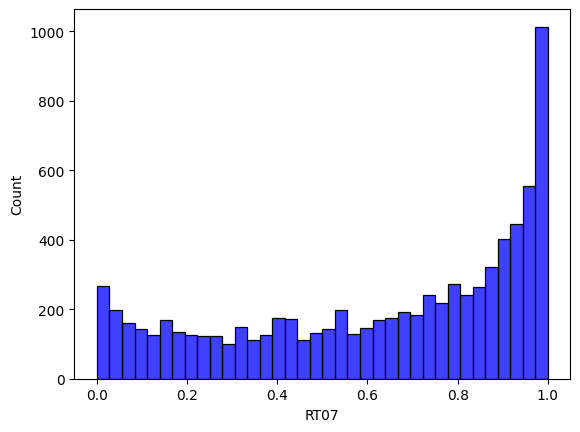

In [ ]:
sns.histplot(dataset2['RT07'], bins=int(180/5), color='blue',  edgecolor='black')

Nhìn vào mức độ chấp nhận rủi ro năm 2007, có thể thấy rằng một số lượng đáng kể các cá nhân có mức độ chấp nhận rủi ro gần bằng một, có nghĩa là đầu tư nghiêng nhiều hơn về các tài sản rủi ro so với các tài sản không rủi ro. Bây giờ hãy xem xét mức độ chấp nhận rủi ro năm 2009.

<Axes: xlabel='RT09', ylabel='Count'>

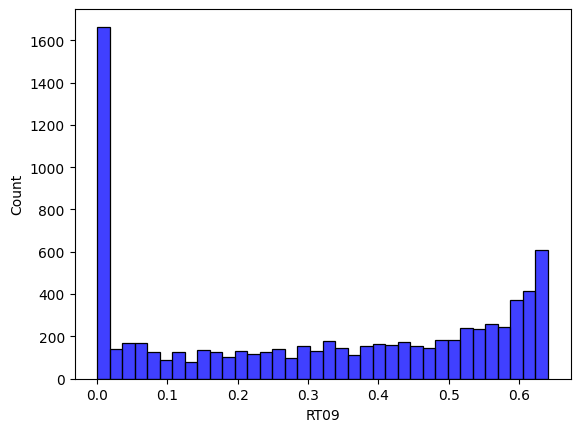

In [ ]:
sns.histplot(dataset2['RT09'], bins=int(180/5), color='blue',  edgecolor='black')

In [ ]:
dataset3 = copy.deepcopy(dataset2)

Rõ ràng, hành vi của các cá nhân đã đảo ngược vào năm 2009 sau khủng hoảng và phần lớn các khoản đầu tư đều vào các tài sản không rủi ro. Nhìn chung, khả năng chấp nhận rủi ro đã giảm, điều này được thể hiện qua việc phần lớn khả năng chấp nhận rủi ro của họ gần bằng 0 vào năm 2009.
Ở bước tiếp theo, nhóm sẽ chọn những nhà đầu tư thông minh có sự thay đổi khả năng chấp nhận rủi ro giữa năm 2007 và 2009 dưới 10%.

In [ ]:
dataset3 = dataset3[dataset3['PercentageChange']<=.1]

Nhóm xác định mức độ chấp nhận rủi ro thực sự là mức độ chấp nhận rủi ro trung bình của các nhà đầu tư thông minh này trong giai đoạn từ năm 2007 đến năm 2009.

Đây là biến số được dự đoán cho trường hợp này. Mục đích là để dự đoán mức độ chấp nhận rủi ro thực sự của một cá nhân dựa trên các đặc điểm về nhân khẩu học, tài chính và mức độ sẵn sàng chấp nhận rủi ro.

In [ ]:
dataset3['TrueRiskTolerance'] = (dataset3['RT07'] + dataset3['RT09'])/2

Nhóm thực hiện loại bỏ những nhãn khác có thể không cần thiết cho quá trình dự đoán.

In [ ]:
dataset3.drop(labels=['RT07', 'RT09'], axis=1, inplace=True)
dataset3.drop(labels=['PercentageChange'], axis=1, inplace=True)

## 3.2. TIỀN XỬ LÝ DỮ LIỆU

Để chọn các đặc trưng có ý nghĩa, nhóm thực hiện phương pháp như sau:
1. Kiểm tra mô tả trong dữ liệu (https://www.federalreserve.gov/econres/files/codebk2009p.txt, https://www.federalreserve.gov/econresdata/scf/files/fedstables.macro.txt) và chỉ giữ lại các đặc trưng có ý nghĩa.
Mô tả của dữ liệu như sau:

* AGE: Có 6 nhóm tuổi, trong đó 1 đại diện cho tuổi dưới 35 và 6 đại diện cho tuổi trên 75.
* EDUC: Có 4 nhóm học vấn, trong đó 1 đại diện cho không tốt nghiệp trung học và 4 đại diện cho bằng đại học.
* MARRIED: Thể hiện tình trạng hôn nhân. Có hai nhóm, trong đó 1 đại diện cho đã kết hôn và 2 đại diện cho chưa kết hôn.
* OCCU: Thể hiện nhóm nghề nghiệp. 1 đại diện cho nhóm quản lý và 4 đại diện cho thất nghiệp.
* KIDS: Thể hiện số lượng con cái.
* NWCAT: Thể hiện nhóm giá trị tài sản ròng. Có 5 hạng mục, trong đó hạng mục 1 đại diện cho giá trị tài sản ròng dưới phân vị thứ 25 và hạng mục 5 đại diện cho giá trị tài sản ròng trên phân vị thứ 90.
* INCCL: Đại diện cho hạng mục thu nhập. Có 5 hạng mục, trong đó hạng mục 1 đại diện cho thu nhập dưới 10.000 và hạng mục 5 đại diện cho giá trị tài sản ròng trên 100.000
* RISK: Đại diện cho mức độ sẵn sàng chấp nhận rủi ro trên thang điểm từ 1 đến 4, trong đó 1 đại diện cho mức độ sẵn sàng chấp nhận rủi ro cao nhất.

2. Chỉ giữ lại các yếu tố trực quan từ năm 2007 và loại bỏ tất cả các đặc trưng trung gian và các đặc trưng liên quan đến năm 2009, vì các biến số của năm 2007 là những biến số duy nhất cần thiết để dự đoán khả năng chịu rủi ro.

In [ ]:
keep_list2 = ['AGE07','EDCL07','MARRIED07','KIDS07','OCCAT107','INCOME07','RISK07','NETWORTH07','TrueRiskTolerance'
]

drop_list2 = [col for col in dataset3.columns if col not in keep_list2]

dataset3.drop(labels=drop_list2, axis=1, inplace=True)

<Axes: title={'center': 'Ma trận nhầm lẫn'}>

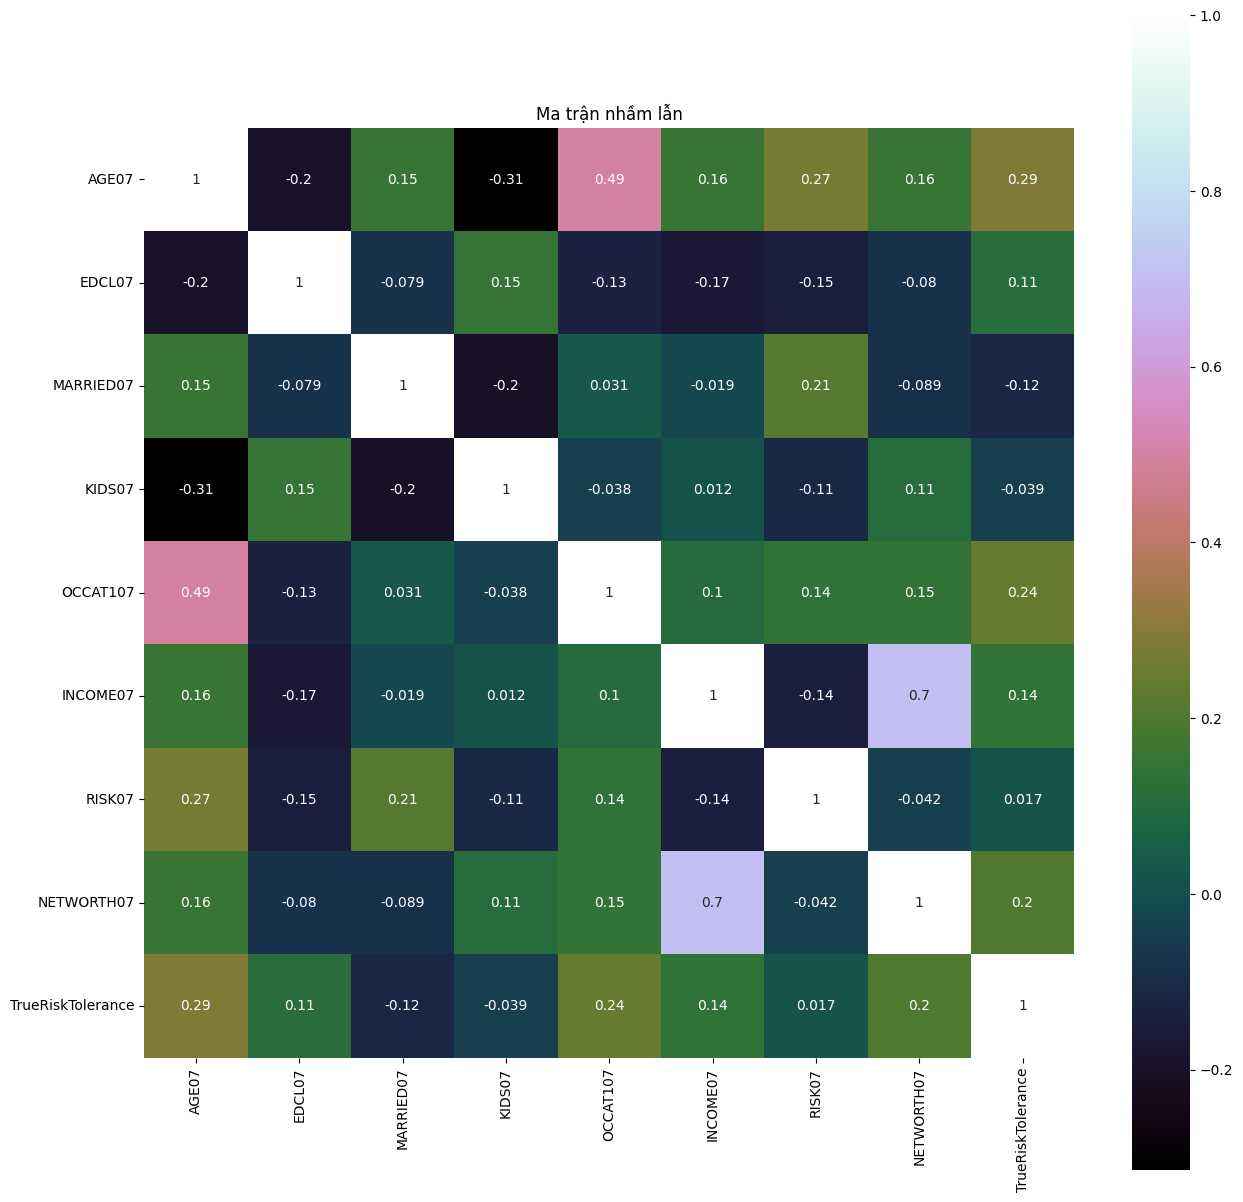

In [ ]:
correlation = dataset3.corr()
plt.figure(figsize=(15,15))
plt.title('Ma trận nhầm lẫn')
sns.heatmap(correlation, vmax=1, square=True,annot=True,cmap='cubehelix')

Nhìn vào biểu đồ tương quan ở trên, giá trị tài sản ròng và thu nhập có tương quan thuận với khả năng chấp nhận rủi ro.

Khả năng chấp nhận rủi ro giảm khi số con cái và số lần kết hôn tăng. Khi sự sẵn lòng chấp nhận rủi ro giảm, khả năng chấp nhận rủi ro cũng giảm. Khả năng chấp nhận rủi ro có mối quan hệ tích cực với tuổi tác.

Theo bài báo "Khả năng chấp nhận rủi ro có giảm theo tuổi tác không? (Hui Wang1, Sherman Hanna)", mức độ né tránh rủi ro tương đối giảm khi con người già đi (tức là tỷ lệ tài sản ròng đầu tư vào tài sản rủi ro tăng lên khi con người già đi) khi các biến số khác được giữ không đổi. Do đó, khả năng chấp nhận rủi ro tăng theo tuổi tác.

Tóm lại, tất cả các biến số và mối quan hệ của chúng với khả năng chấp nhận rủi ro có vẻ có ý nghĩa.

<Figure size 1500x1500 with 0 Axes>

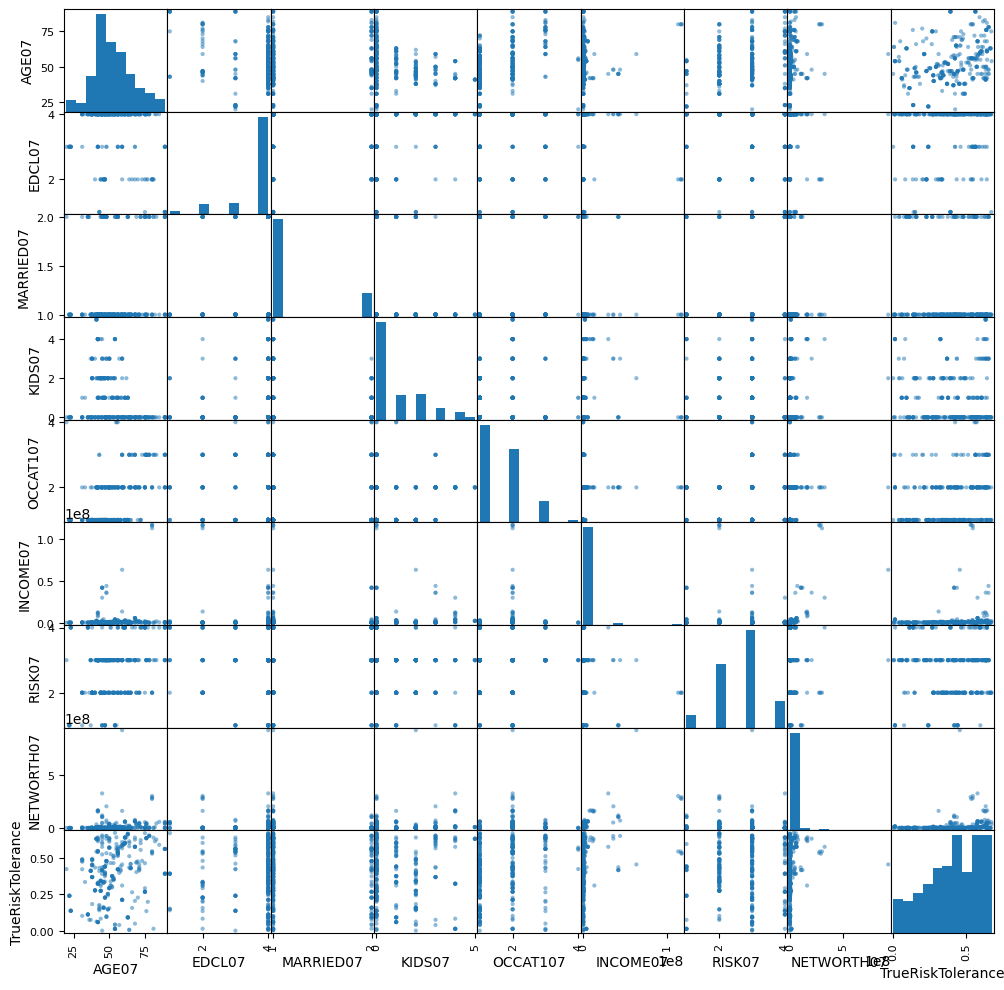

In [ ]:
from pandas.plotting import scatter_matrix
plt.figure(figsize=(15,15))
scatter_matrix(dataset3,figsize=(12,12))
plt.show()

# 4. ĐÁNH GIÁ CÁC THUẬT TOÁN VÀ MÔ HÌNH

## 4.1. CHIA TẬP DỮ LIỆU

In [ ]:
Y= dataset3["TrueRiskTolerance"]
X = dataset3.loc[:, dataset3.columns != 'TrueRiskTolerance']
validation_size = 0.2
seed = 3
X_train, X_validation, Y_train, Y_validation = train_test_split(X, Y, test_size=validation_size, random_state=seed)

## 4.2. ĐIỀU CHỈNH CÁC CHỈ SỐ KIỂM THỬ VÀ CHỈ SỐ ĐÁNH GIÁ

In [ ]:
num_folds = 10
scoring = 'r2'

## 4.3. SO SÁNH CÁC MÔ HÌNH VÀ CÁC THUẬT TOÁN

### Regression Models

In [ ]:
models = []
models.append(('LR', LinearRegression()))
models.append(('LASSO', Lasso()))
models.append(('CART', DecisionTreeRegressor()))
models.append(('ABR', AdaBoostRegressor()))
models.append(('GBR', GradientBoostingRegressor()))
models.append(('RFR', RandomForestRegressor()))

### K-folds cross validation

In [ ]:
results = []
names = []
for name, model in models:
    kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
    cv_results = -1* cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

LR: -0.102704 (0.179297)
LASSO: -0.041555 (0.109033)
CART: -0.544903 (0.219292)
ABR: -0.382640 (0.146700)
GBR: -0.620374 (0.142305)
RFR: -0.716000 (0.105880)


### SO SÁNH CÁC THUẬT TOÁN

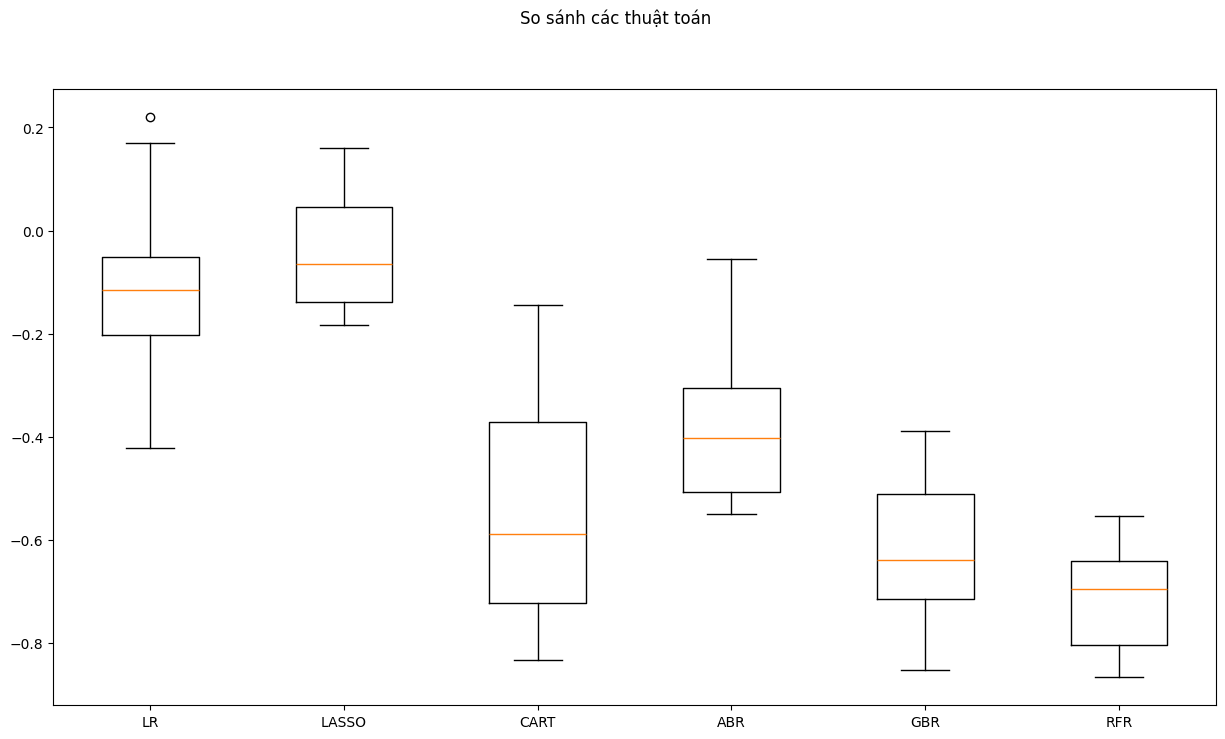

In [ ]:
fig = plt.figure()
fig.suptitle('So sánh các thuật toán')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
fig.set_size_inches(15,8)
plt.show()

Các mô hình phi tuyến tính hoạt động tốt hơn các mô hình tuyến tính, điều này có nghĩa là có mối quan hệ phi tuyến tính giữa mức độ chấp nhận rủi ro và các biến khác biệt được sử dụng để dự đoán nó.

Vì Random Forest Regressor là một trong những phương pháp tốt nhất, nhóm quyết định sử dụng thuật toán này để thực hiện phương pháp tinh chỉnh siêu tham số Grid Search cho việc cải thiện hiệu suất mô hình.

# 5. TINH CHỈNH MÔ HÌNH VÀ SỬ DỤNG PHƯƠNG PHÁP TÌM KIẾM SIÊU THAM SỐ GRID SEARCH

In [ ]:
param_grid = {'n_estimators': [50,100,150,200,250,300,350,400]}
model = RandomForestRegressor()
kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, cv=kfold)
grid_result = grid.fit(X_train, Y_train)
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.715004 using {'n_estimators': 300}
0.699035 (0.116959) with: {'n_estimators': 50}
0.714397 (0.101964) with: {'n_estimators': 100}
0.697437 (0.103753) with: {'n_estimators': 150}
0.710890 (0.108140) with: {'n_estimators': 200}
0.711139 (0.097585) with: {'n_estimators': 250}
0.715004 (0.097501) with: {'n_estimators': 300}
0.711852 (0.096537) with: {'n_estimators': 350}
0.706374 (0.106756) with: {'n_estimators': 400}


Random forest với 'n_estimators'=300 là mô hình tốt nhất sau khi tìm kiếm siêu tham số tối ưu hóa.

# 6. HOÀN THIỆN MÔ HÌNH

Hoàn thiện mô hình với các thông số tối ưu nhất tìm được trong bước tinh chỉnh.

## 6.1. KẾT QUẢ TRÊN TẬP KIỂM THỬ

In [ ]:
model = RandomForestRegressor(n_estimators = 300)
model.fit(X_train, Y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
from sklearn.metrics import r2_score
predictions_train = model.predict(X_train)
print(r2_score(Y_train, predictions_train))

0.9658655363400952


In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
predictions = model.predict(X_validation)
print(mean_squared_error(Y_validation, predictions))
print(r2_score(Y_validation, predictions))

0.0074216062876013116
0.7724923636186721


Dựa trên sai số bình phương trung bình và hệ số R2 được hiển thị ở trên cho tập dữ liệu thử nghiệm, kết quả có vẻ tương đối tốt.

## 6.2. CÁC ĐẶC TRƯNG QUAN TRỌNG VÀ Ý NGHĨA

[0.22040679 0.02519379 0.01448079 0.04659389 0.0260091  0.23750902
 0.05149562 0.37831099]


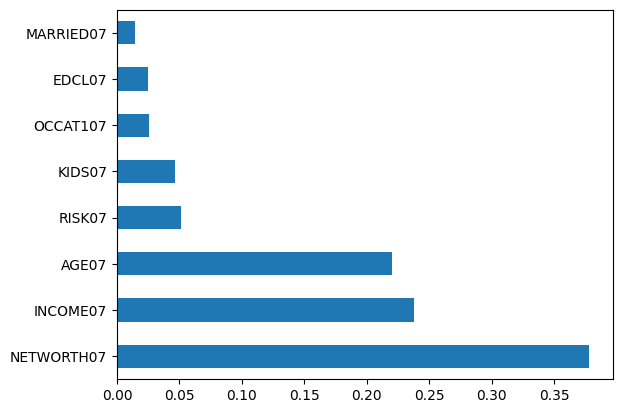

In [ ]:
import pandas as pd
import numpy as np
model = RandomForestRegressor(n_estimators= 200,n_jobs=-1)
model.fit(X_train,Y_train)
print(model.feature_importances_)
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.show()

Từ biểu đồ trên, thu nhập và giá trị tài sản ròng, tiếp theo là tuổi tác và mức độ sẵn sàng chấp nhận rủi ro, là những biến số chính để quyết định khả năng chịu đựng rủi ro.

Những biến số này đã được xem xét là các biến số quan trọng để mô hình hóa khả năng chịu đựng rủi ro trong nhiều tài liệu nghiên cứu.

## 6.3. LƯU MODEL

In [ ]:
from pickle import dump
from pickle import load

filename = 'finalized_model.sav'
dump(model, open(filename, 'wb'))

In [ ]:
loaded_model = load(open(filename, 'rb'))
predictions = loaded_model.predict(X_validation)
result = mean_squared_error(Y_validation, predictions)
print(r2_score(Y_validation, predictions))
print(result)

0.746802703648081
0.008259637682927815


__KẾT LUẬN__:

Với kết quả trên, nhóm đã chứng minh rằng các mô hình học máy có thể phân tích một cách khách quan hành vi của các nhà đầu tư khác nhau trong một thị trường biến động và quy kết những thay đổi này cho các biến số liên quan đến việc xác định mức độ chấp nhận rủi ro.

Có một mối quan hệ phi tuyến tính giữa các biến số và khả năng chấp nhận rủi ro. Thu nhập và giá trị tài sản ròng, tiếp theo là tuổi tác và sự sẵn sàng chấp nhận rủi ro, là những biến quyết định khả năng chấp nhận rủi ro. Những biến này đã được xem xét là các biến quan trọng để mô hình hóa khả năng chấp nhận rủi ro trong nhiều tài liệu nghiên cứu.